In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from IPython.display import display
import scipy.stats as stats

In [2]:
stocks_info = {
    'NVDA': {'color': 'navy', 'file': 'data/NVIDIA Stock Price History.csv'},
    'AMD': {'color': 'orange', 'file': 'data/AMD Stock Price History.csv'},
    'AVGO': {'color': 'green', 'file': 'data/Broadcom Stock Price History.csv'},
    'INTC': {'color': 'skyblue', 'file': 'data/Intel Stock Price History.csv'},
}

NVDA - Loading data from data/NVIDIA Stock Price History.csv
AMD - Loading data from data/AMD Stock Price History.csv
AVGO - Loading data from data/Broadcom Stock Price History.csv
INTC - Loading data from data/Intel Stock Price History.csv


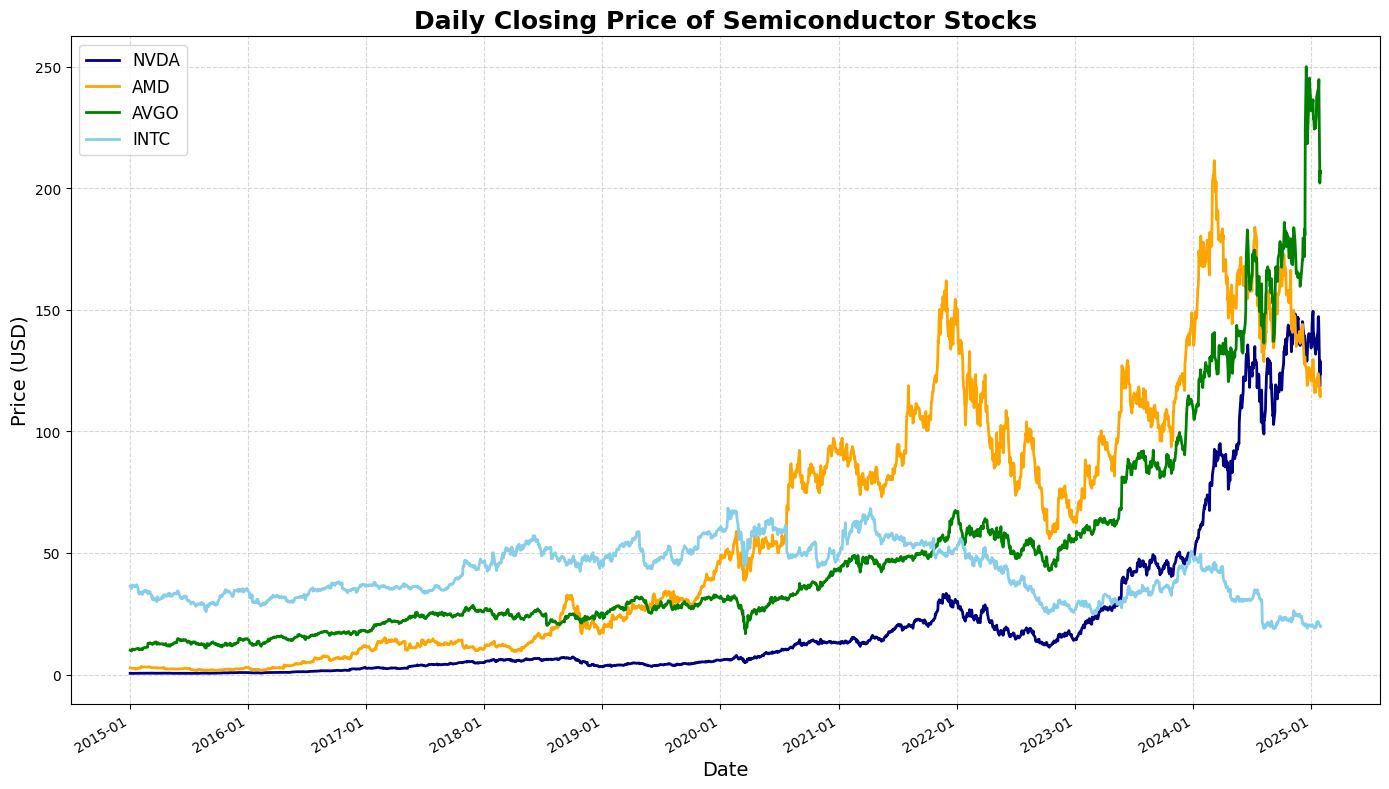

In [3]:
plt.figure(figsize=(14, 8))

for symbol, info in stocks_info.items():
    file_path = info['file']
    color = info['color']

    if not os.path.exists(file_path):
        print(f"File Error: {file_path} does not exists.")
        continue

    print(f"{symbol} - Loading data from {file_path}")

    df = pd.read_csv(file_path)

    df['Date'] = pd.to_datetime(df['Date'])

    df = df[df['Date'] != pd.to_datetime('2016-02-27')]

    df = df.sort_values('Date')

    df['Return'] = df['Price'].pct_change()

    if df['Price'].dtype == 'object':
        df['Price'] = df['Price'].str.replace(',', '').astype(float)

    df = df.sort_values('Date')

    plt.plot(df['Date'], df['Price'], label = symbol, color = color, linewidth = 2)

plt.title('Daily Closing Price of Semiconductor Stocks', fontsize = 18, fontweight = 'bold')
plt.xlabel('Date', fontsize = 14)
plt.ylabel('Price (USD)', fontsize = 14)
plt.legend(loc = 'upper left', fontsize = 12, frameon = True)
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [4]:
assets_info = {
    'DJI': {'color': 'navy', 'file': 'data/Dow Jones Industrial Average Historical Data.csv', 'label': 'Index Value',
            },
    'DJI_mod': {'color': 'navy', 'file': 'data/Dow Jones Industrial Average Historical Data.csv', 'label': 'Index Value',
            'ylim': (0, 15000), 'ystep': 2500},
    'XAU': {'color': 'navy', 'file': 'data/XAU_USD Historical Data.csv', 'label': 'Price (USD per ounce)',
            'ylim': (0, 3000), 'ystep': 500},
    'EUR': {'color': 'navy', 'file': 'data/EUR_USD Historical Data.csv', 'label': 'Price (USD per EUR)',
            'ylim': (0.8, 1.4), 'ystep': 0.1},
    'WTI': {'color': 'navy', 'file': 'data/WTI_USD Historical Data.csv', 'label': 'Price (USD/bbl)',
            'ylim': (0, 140), 'ystep': 20},
    'BTC': {'color': 'navy', 'file': 'data/Bitcoin Historical Data.csv', 'label': 'Price (USD/BTC)',
            'ylim': (0, 120000), 'ystep': 20000},
}

DJI - Loading data from data/Dow Jones Industrial Average Historical Data.csv
DJI_mod - Loading data from data/Dow Jones Industrial Average Historical Data.csv
XAU - Loading data from data/XAU_USD Historical Data.csv
EUR - Loading data from data/EUR_USD Historical Data.csv
WTI - Loading data from data/WTI_USD Historical Data.csv
BTC - Loading data from data/Bitcoin Historical Data.csv


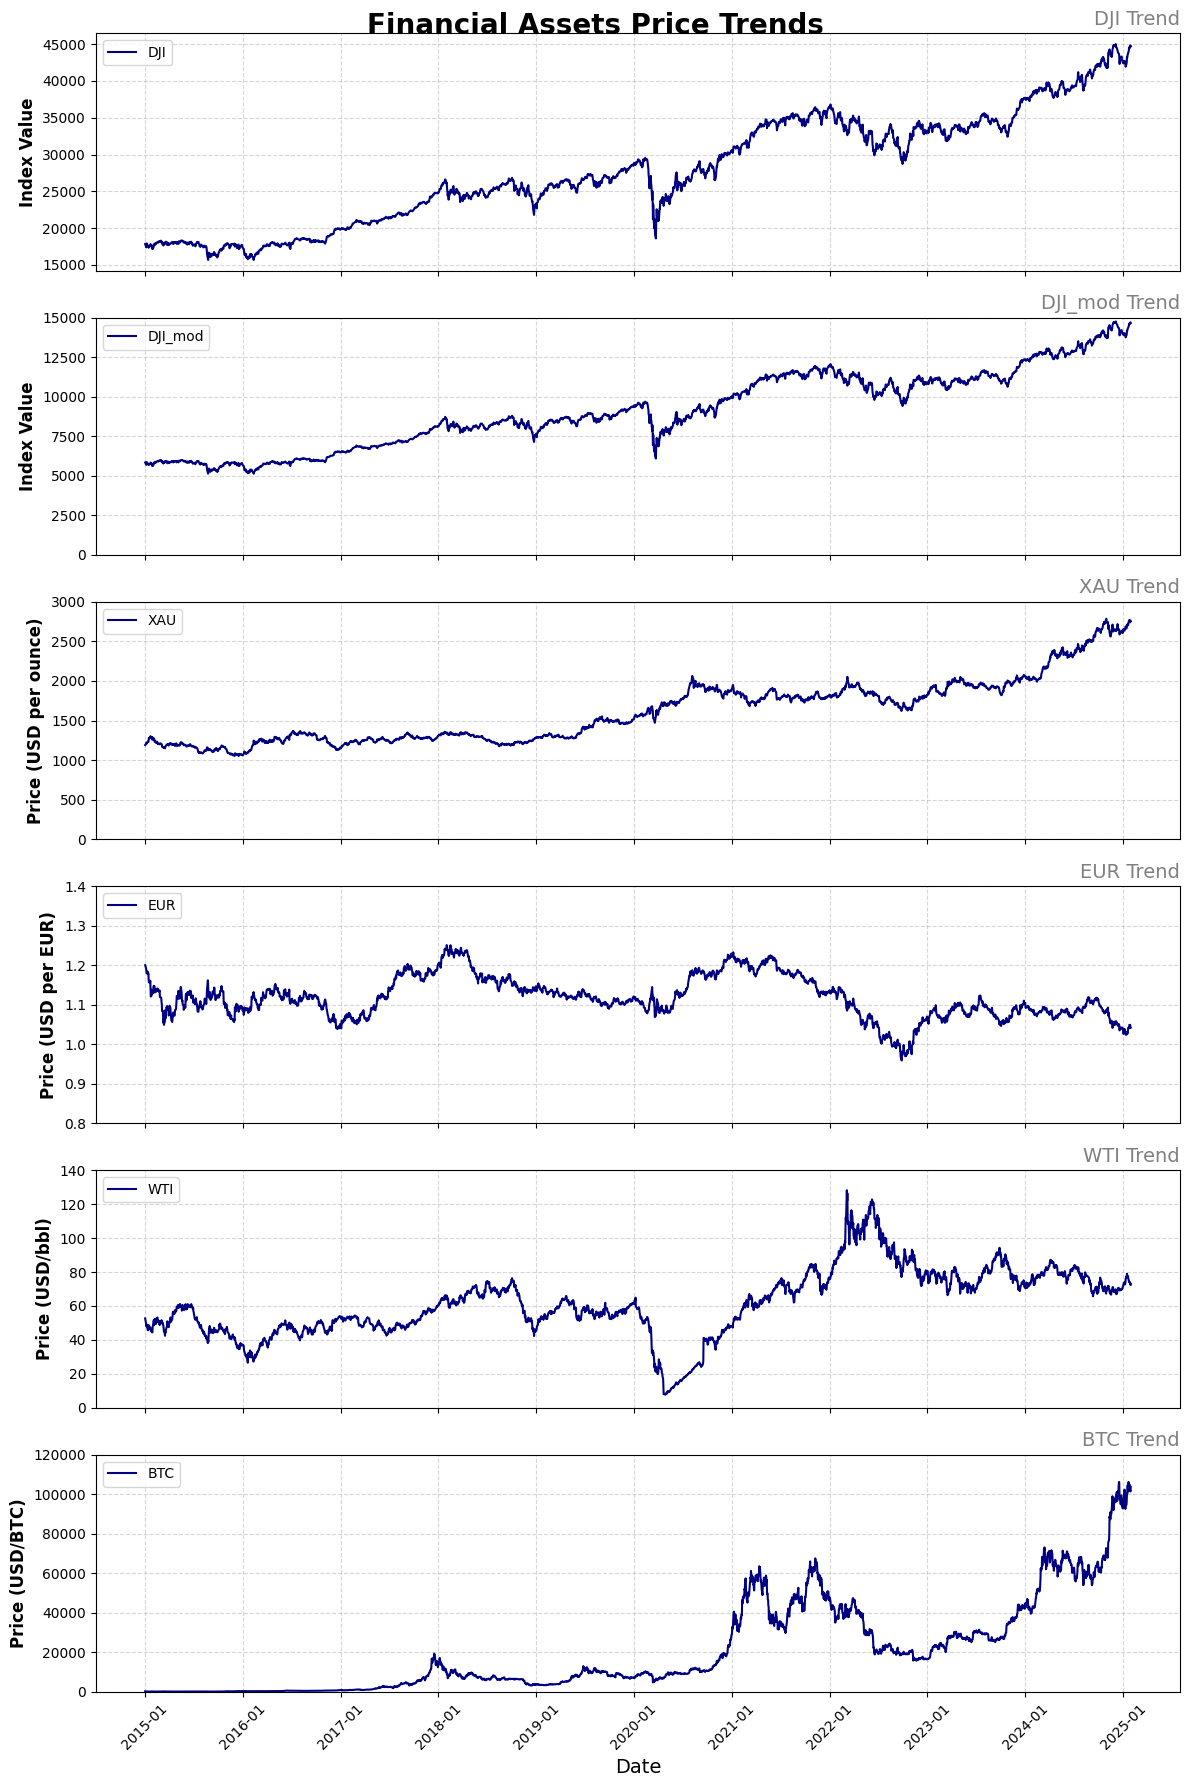

In [5]:
fig, axes = plt.subplots(nrows = 6, ncols = 1, figsize = (12, 20), sharex = True)

for i, (symbol, info) in enumerate(assets_info.items()):
    ax = axes[i]
    file_path = info['file']

    if not os.path.exists(file_path):
        print((f"File Error: {file_path} does not exists."))
        ax.text(0.5, 0.5, f"{symbol} data not found", ha = 'center', va = 'center')
        continue

    print(f"{symbol} - Loading data from {file_path}")

    df = pd.read_csv(file_path)

    df['Date'] = pd.to_datetime(df['Date'])

    price_col = 'Price' if 'Price' in df.columns else 'Close'

    if df[price_col].dtype == 'object':
        df[price_col] = df[price_col].str.replace(',', '').astype(float)

    df = df.sort_values('Date')

    if symbol == 'DJI_mod':
        df[price_col] = df[price_col] / 3.05

    ax.plot(df['Date'], df[price_col], label = symbol, color = info['color'], linewidth = 1.5)
    
    if 'ylim' in info:
        ymin, ymax = info['ylim']
        ax.set_ylim(ymin, ymax)

        if 'ystep' in info:
            step = info['ystep']
            ticks = np.arange(ymin, ymax + (step/1000), step)
            ax.set_yticks(ticks)

    ax.set_ylabel(info['label'], fontsize = 12, fontweight = 'bold')
    ax.legend(loc = 'upper left', fontsize = 10, frameon = True)
    ax.grid(True, linestyle = '--', alpha = 0.5)

    ax.set_title(f"{symbol} Trend", fontsize = 14, loc = 'right', color = 'gray')

plt.xlabel('Date', fontsize = 14)
plt.xticks(rotation = 45)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('Financial Assets Price Trends', fontsize = 20, fontweight = 'bold', y = 0.92)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
file_map = {
    # Semiconductor Stocks
    'NVDA': 'data/NVIDIA Stock Price History.csv',
    'AMD': 'data/AMD Stock Price History.csv',
    'AVGO': 'data/Broadcom Stock Price History.csv',
    'INTC': 'data/Intel Stock Price History.csv',
    # Financial Assets
    'DJI': 'data/Dow Jones Industrial Average Historical Data.csv',
    'XAU': 'data/XAU_USD Historical Data.csv',
    'EUR': 'data/EUR_USD Historical Data.csv',
    'WTI': 'data/WTI_USD Historical Data.csv',
    'BTC': 'data/Bitcoin Historical Data.csv',
}


,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
Mean,0.22%,0.15%,0.12%,-0.02%,0.04%,0.03%,-0.01%,0.01%,0.23%
Std Dev,3.08%,3.63%,2.38%,2.28%,1.11%,0.89%,0.50%,2.89%,4.39%
Min,-20.79%,-27.75%,-22.19%,-30.19%,-13.84%,-5.90%,-2.40%,-41.77%,-49.73%
Max,26.37%,42.06%,21.86%,17.83%,10.76%,4.69%,3.04%,40.35%,24.08%


,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
NVDA,1.00,0.59,0.60,0.47,0.52,0.01,0.04,0.12,0.20
AMD,0.59,1.00,0.45,0.38,0.42,0.03,0.07,0.12,0.14
AVGO,0.60,0.45,1.00,0.50,0.58,0.03,0.05,0.18,0.15
INTC,0.47,0.38,0.50,1.00,0.58,0.04,0.02,0.16,0.16
DJI,0.52,0.42,0.58,0.58,1.00,0.01,0.08,0.28,0.21
XAU,0.01,0.03,0.03,0.04,0.01,1.00,0.37,0.08,0.09
EUR,0.04,0.07,0.05,0.02,0.08,0.37,1.00,0.04,0.06
WTI,0.12,0.12,0.18,0.16,0.28,0.08,0.04,1.00,0.05
BTC,0.20,0.14,0.15,0.16,0.21,0.09,0.06,0.05,1.00


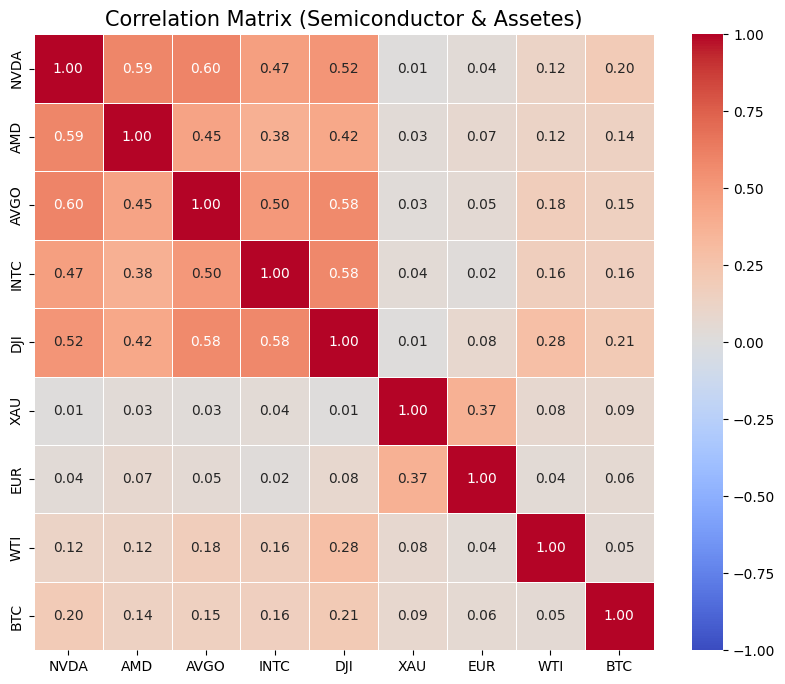

In [7]:
def load_data(file_map):
    df = pd.DataFrame()

    for symbol, file_path in file_map.items():
        if not os.path.exists(file_path):
            print(f"File Error: {file_path} does not exists.")
            continue

        temp_df = pd.read_csv(file_path)
        temp_df['Date'] = pd.to_datetime(temp_df['Date'])

        col_name = 'Price' if 'Price' in temp_df.columns else 'Close'
        if temp_df[col_name].dtype == 'object':
            temp_df[col_name] = temp_df[col_name].str.replace(',', '').astype(float)

        temp_df = temp_df.sort_values('Date').set_index('Date')
        temp_df = temp_df[[col_name]].rename(columns={col_name: symbol})

        if df.empty:
            df = temp_df
        else:
            df = df.join(temp_df, how = 'inner')
    return df

df_price = load_data(file_map)

log_returns_pct = np.log(df_price / df_price.shift(1)) * 100
log_returns_pct = log_returns_pct.dropna()

table1 = log_returns_pct.describe().T[['mean', 'std', 'min', 'max']]

table1.columns = ['Mean', 'Std Dev', 'Min', 'Max']

table1 = table1.T

display(table1.style.format("{:.2f}%"))
print("="*50)

table2 = log_returns_pct.corr(method = 'pearson')
display(table2.style.background_gradient(cmap = 'coolwarm', axis = None).format("{:.2f}"))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(table2, dtype = bool))
sns.heatmap(table2, annot = True, fmt = ".2f", cmap = 'coolwarm', linewidth = 0.5, vmin = -1, vmax = 1, center = 0)
plt.title('Correlation Matrix (Semiconductor & Assetes)', fontsize = 15)
plt.show()

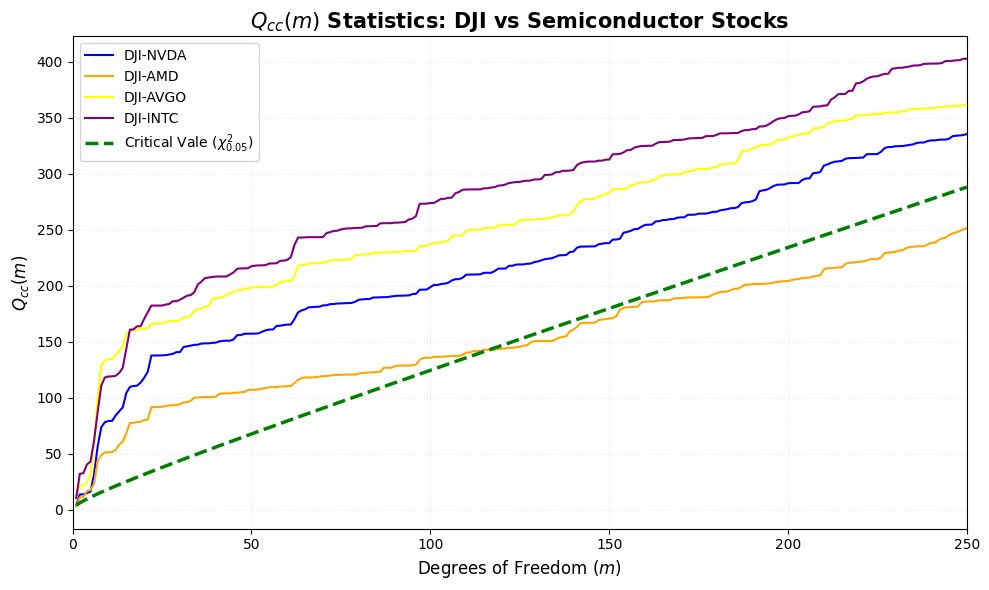

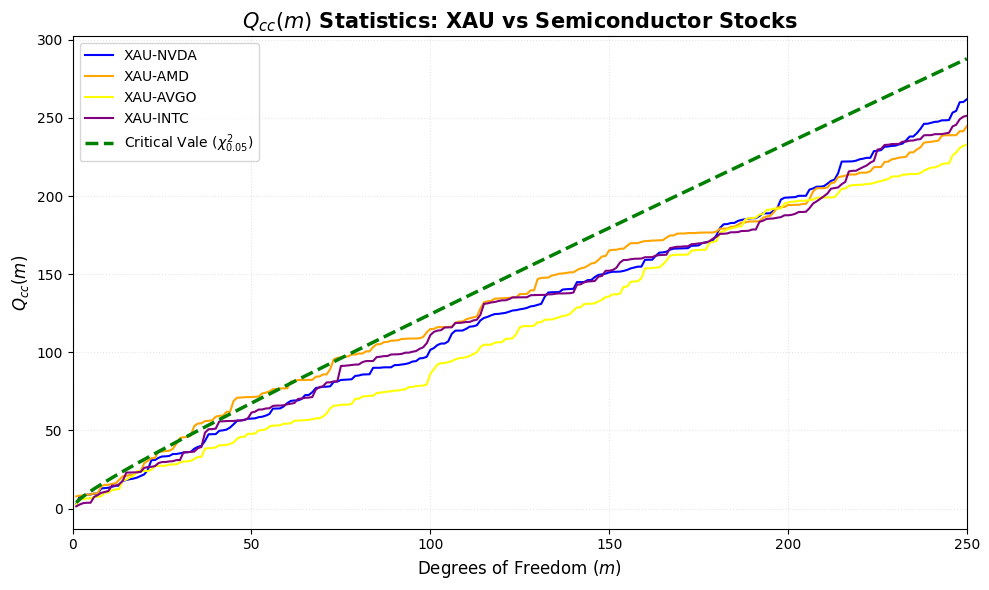

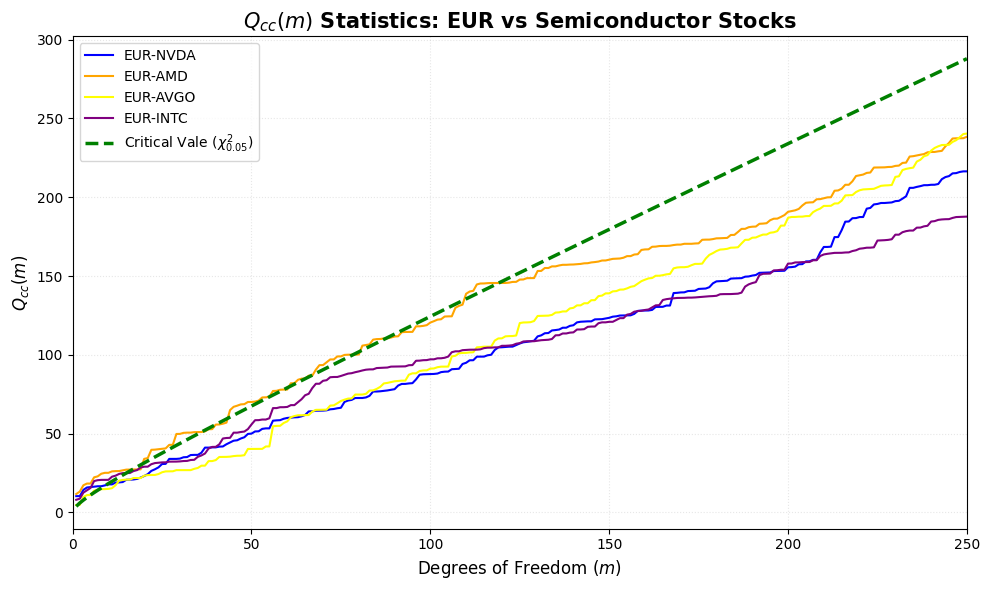

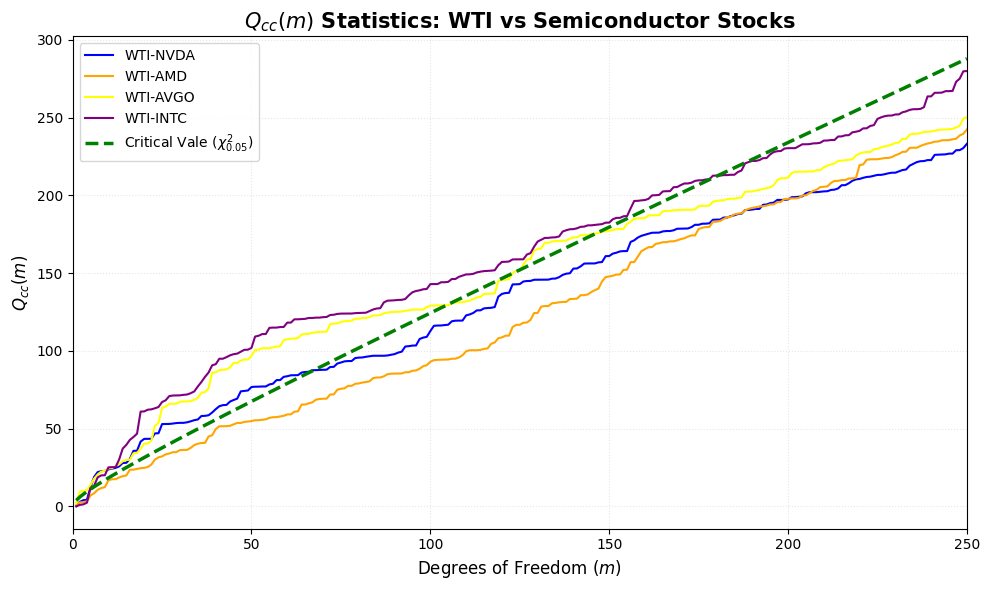

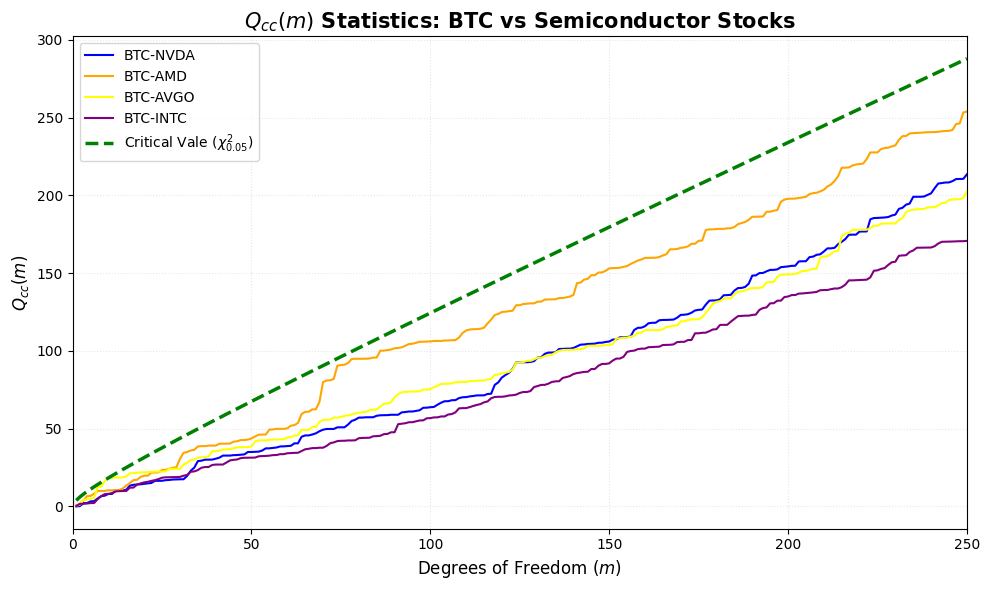

In [11]:
semi_stock = ['NVDA', 'AMD', 'AVGO', 'INTC']
financial_assets = ['DJI', 'XAU', 'EUR', 'WTI', 'BTC']

log_returns = np.log(df_price / df_price.shift(1)).dropna()

def calculate_qcc(series_x, series_y, max_m = 250):
    common_df = pd.concat([series_x, series_y], axis = 1).dropna()
    x = common_df.iloc[:, 0].values
    y = common_df.iloc[:, 1].values
    N = len(x)

    if N < max_m + 10: return None

    x_norm = (x - x.mean()) / x.std()
    y_norm = (y - y.mean()) / y.std()

    q_cc_list = []
    sum_rho_sq_div_n_i = 0

    for m in range(1, max_m + 1):
        numerator = np.dot(x_norm[m:], y_norm[:-m])
        rho_m = numerator / (N - 1)
        sum_rho_sq_div_n_i += (rho_m ** 2) / (N - m)
        q_stat = (N ** 2) * sum_rho_sq_div_n_i
        q_cc_list.append(q_stat)

    return q_cc_list

max_m_val = 250
m_range = range(1, max_m_val + 1)

critical_values = [stats.chi2.ppf(0.95, df = m) for m in m_range]

colors = {'NVDA': 'blue', 'AMD': 'orange', 'AVGO': 'yellow', 'INTC': 'purple'}

for asset in financial_assets:
    if asset not in log_returns.columns: continue

    plt.figure(figsize = (10, 6))
    asset_data = log_returns[asset]
    plot_exists = False

    for stock in semi_stock:
        if stock not in log_returns.columns: continue

        q_stats = calculate_qcc(asset_data, log_returns[stock], max_m = max_m_val)

        if q_stats is not None:
            plt.plot(m_range, q_stats, label = f'{asset}-{stock}', color = colors[stock], linewidth = 1.5)
            plot_exists = True
    
    if plot_exists:
        plt.plot(m_range, critical_values, label = 'Critical Vale ($\chi^2_{0.05}$)',
                 color = 'green', linestyle = '--', linewidth = 2.5)
        
        plt.title(f'$Q_{{cc}}(m)$ Statistics: {asset} vs Semiconductor Stocks', fontsize = 15, fontweight = 'bold')
        plt.xlabel('Degrees of Freedom ($m$)', fontsize = 12)
        plt.ylabel('$Q_{{cc}}(m)$', fontsize = 12)
        plt.legend(loc = 'upper left', fontsize = 10)
        plt.grid(True, linestyle = ':', alpha = 0.3)
        plt.xlim(0, 250)

        plt.tight_layout()
        plt.show()


In [23]:
import yfinance as yf

start_date = '2015-01-02'
end_date = '2025-01-29'

tickers = {
    'NVDA': 'NVDA', 'AMD': 'AMD', 'AVGO': 'AVGO', 'INTC': 'INTC',
    'DJI': '^DJI', 'XAU': 'GC=F', 'EUR': 'EURUSD=X', 'WTI': 'CL=F', 'BTC': 'BTC-USD'
}

data = yf.download(list(tickers.values()), start = start_date, end = end_date, progress = False)

if isinstance(data.columns, pd.MultiIndex):
    df_prices = data['Close']
else:
    df_prices = data
    

inv_tickers = {v: k for k, v in tickers.items()}
df_prices_yf = df_prices.rename(columns = inv_tickers)

new_order = semi_stock + financial_assets
valid_columns = [col for col in new_order if col in df_prices_yf.columns]
df_prices_yf = df_prices_yf[valid_columns]


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31308\2113301345.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), start = start_date, end = end_date, progress = False)


c:\Users\kjw02\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Ticker,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
Mean,0.21%,0.07%,0.15%,-0.03%,0.05%,0.04%,0.00%,0.13%,0.12%
Std Dev,2.97%,3.65%,2.37%,2.33%,1.07%,0.92%,0.50%,2.83%,3.94%
Min,-20.77%,-27.75%,-17.27%,-30.19%,-10.52%,-4.74%,-2.81%,-27.99%,-46.47%
Max,21.81%,42.06%,21.86%,17.83%,10.76%,5.78%,2.81%,31.96%,22.51%


Ticker,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
Ticker,,,,,,,,,
NVDA,1.00,0.59,0.59,0.46,0.53,0.01,-0.01,0.11,0.19
AMD,0.59,1.00,0.44,0.36,0.44,0.02,-0.01,0.10,0.14
AVGO,0.59,0.44,1.00,0.47,0.57,0.03,-0.00,0.17,0.18
INTC,0.46,0.36,0.47,1.00,0.56,0.03,-0.01,0.12,0.18
DJI,0.53,0.44,0.57,0.56,1.00,0.03,0.02,0.24,0.23
XAU,0.01,0.02,0.03,0.03,0.03,1.00,0.06,0.10,0.09
EUR,-0.01,-0.01,-0.00,-0.01,0.02,0.06,1.00,-0.02,-0.01
WTI,0.11,0.10,0.17,0.12,0.24,0.10,-0.02,1.00,0.06
BTC,0.19,0.14,0.18,0.18,0.23,0.09,-0.01,0.06,1.00


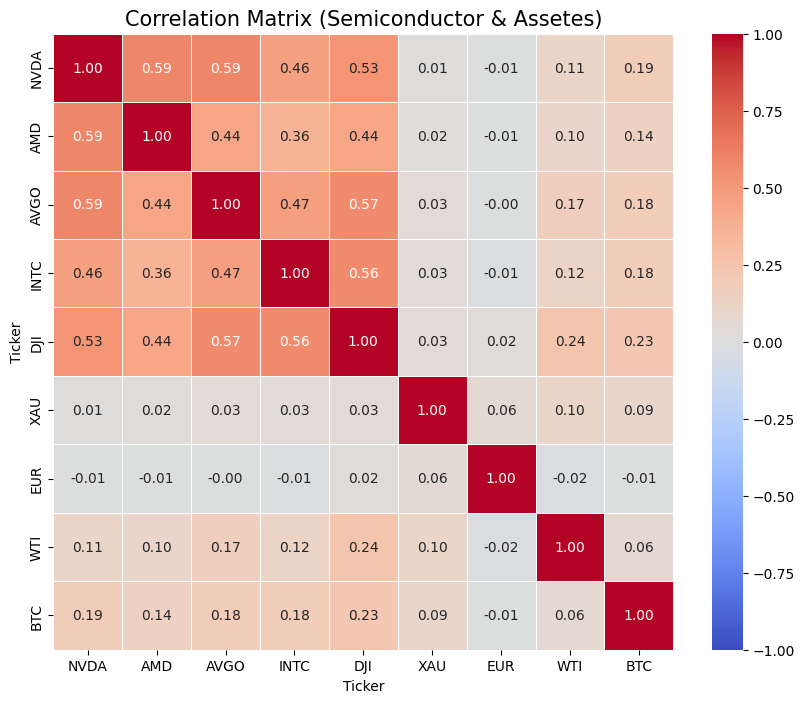

In [24]:
log_returns_pct = np.log(df_prices_yf / df_prices_yf.shift(1)) * 100
log_returns_pct = log_returns_pct.dropna()

table1 = log_returns_pct.describe().T[['mean', 'std', 'min', 'max']]

table1.columns = ['Mean', 'Std Dev', 'Min', 'Max']

table1 = table1.T

display(table1.style.format("{:.2f}%"))
print("="*50)

table2 = log_returns_pct.corr(method = 'pearson')
display(table2.style.background_gradient(cmap = 'coolwarm', axis = None).format("{:.2f}"))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(table2, dtype = bool))
sns.heatmap(table2, annot = True, fmt = ".2f", cmap = 'coolwarm', linewidth = 0.5, vmin = -1, vmax = 1, center = 0)
plt.title('Correlation Matrix (Semiconductor & Assetes)', fontsize = 15)
plt.show()